In [1]:
""" Exam 2 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\2599092534.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\2599092534.py:35: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


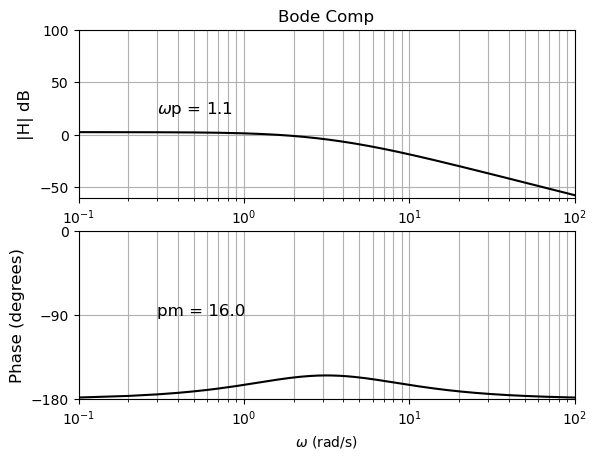

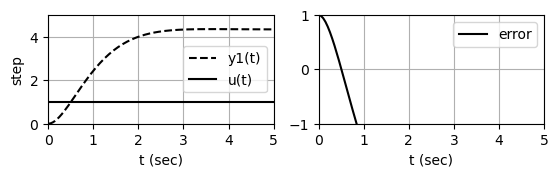

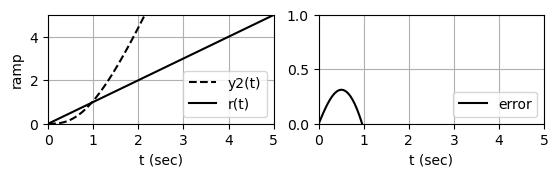

In [2]:
K = 1.3
n1 = [0, 0, 10]
d1 = [1, 3, -10]

n2 = [0, 1, 0]
d2 = [0, 1, 0]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,1e2,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 100])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-90,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,5])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,5,-1,1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,0,1])
plt.grid()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\1169256939.py:23: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,50,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\1169256939.py:35: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')


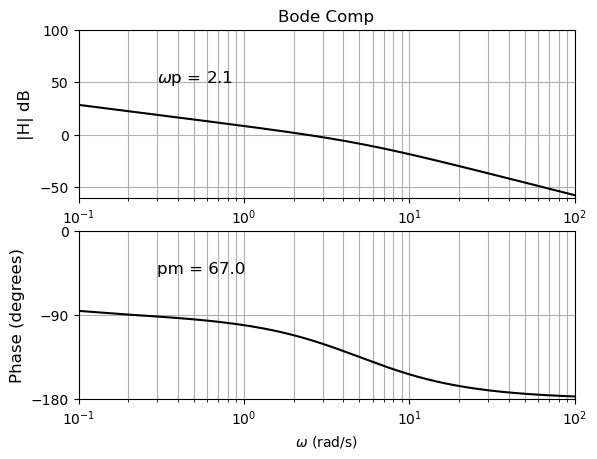

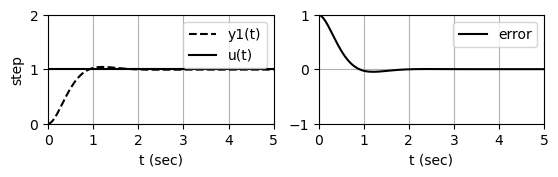

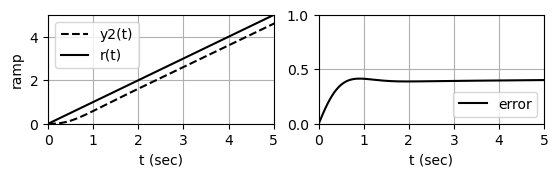

In [3]:
K = 1.3
n1 = [0, 0, 10]
d1 = [1, 3, -10]

n2 = [0, 1, -2]
d2 = [0, 1, 0.01]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,1e2,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 100])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,50,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-45,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,5,-1,1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,0,1])
plt.grid()
plt.show()

In [4]:
""" Phase Lead Calculations """

p_m = 75 *(np.pi/180)
a = (1+np.sin(p_m))/(1-np.sin(p_m))
print("a =", a)
w_m = -10*np.log10(a)
print("w_m =", w_m)

a = 57.69548054098108
w_m = -17.611417949064048


In [5]:
# Use this function to find corresponding w
center_freq = 9.33 #rad/s
w_guess = np.interp(center_freq, w, Hmag)
print(w_m, "=", w_guess)

-17.611417949064048 = -17.612697264595084


In [6]:
w_p = np.sqrt(a)*center_freq
w_z = center_freq/np.sqrt(a)
print("w_m =", center_freq, "rad/s")
print("w_p =", w_p, "rad/s")
print("w_z =", w_z, "rad/s")

w_m = 9.33 rad/s
w_p = 70.86838587172568 rad/s
w_z = 1.228317802490403 rad/s


<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
<>:30: SyntaxWarning: invalid escape sequence '\o'
<>:42: SyntaxWarning: invalid escape sequence '\o'
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\2315142125.py:30: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\gjsta\AppData\Local\Temp\ipykernel_75664\2315142125.py:42: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\gjsta\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


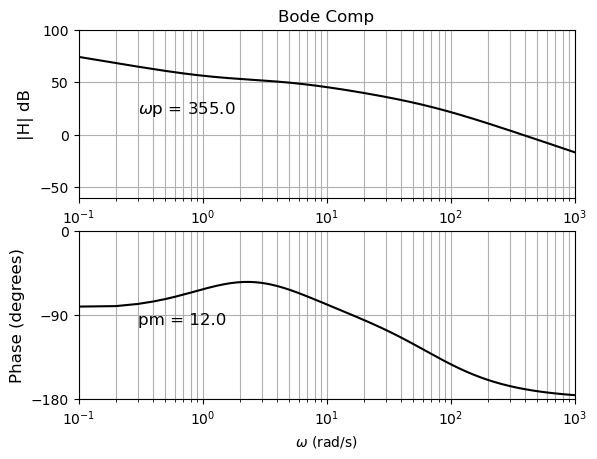

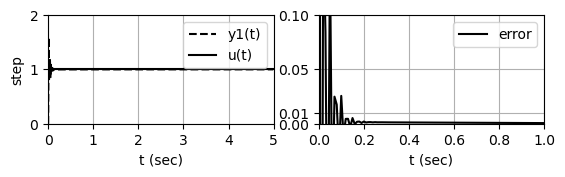

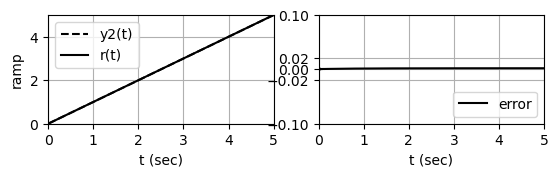

In [16]:
""" Phase Lead Implementation """

K = 250*(w_p/w_z)
n1 = [0, 0, 10]
d1 = [1, 3, -10]

#First Gc
n2 = [0, 1, -2]
d2 = [0, 1, 0.01]
n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

#Second Gc
n3 = [0, 0, 1, w_z]
d3 = [0, 0, 1, w_p]
n123 = np.convolve(n12,n3)
d123 = np.convolve(d12,d3)
num = n123
den = d123

w = np.linspace(0.1,1e3,num=10000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e3, -60, 100])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e3, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-100,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.show()

""" Time portion """

dt = 0.01
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,1,0,0.1])
plt.xlabel('t (sec)')
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.yticks([0, 0.01, 0.05, 0.1])
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,-0.1,0.1])
plt.yticks([-0.1, -0.02, 0, 0.02, 0.1])
plt.grid()
plt.show()